Dataset on cardiovascular disease

Predict the presence or absence of cardiovascular disease (CVD) using the patient examination results.

Part 1. Preliminary data analysis

In [24]:
#import all required modules
#disable warnings

import warnings

import numpy as numpy
import pandas as pd

warnings.filterwarnings("ignore")

#import plotting modules and setup
import seaborn as sns

sns.set()

import matplotlib
import matplotlib.pyplot as plt

import matplotlib.ticker

%matplotlib inline
%config InlineBackend.figure_format = "retina"

Use seaborn library for visual analysis

In [25]:
sns.set_context("notebook", font_scale = 1.5,
                rc = {"figure.figsize" : (11, 8), "axes.titlesize" : 18})

from matplotlib import rcParams

rcParams["figure.figsize"] = 11, 8

In [26]:
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

df = pd.read_csv(DATA_URL + "mlbootcamp5_train.csv", sep=";")

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'active'),
  Text(1, 0, 'alco'),
  Text(2, 0, 'cardio'),
  Text(3, 0, 'cholesterol'),
  Text(4, 0, 'gender'),
  Text(5, 0, 'gluc'),
  Text(6, 0, 'smoke')])

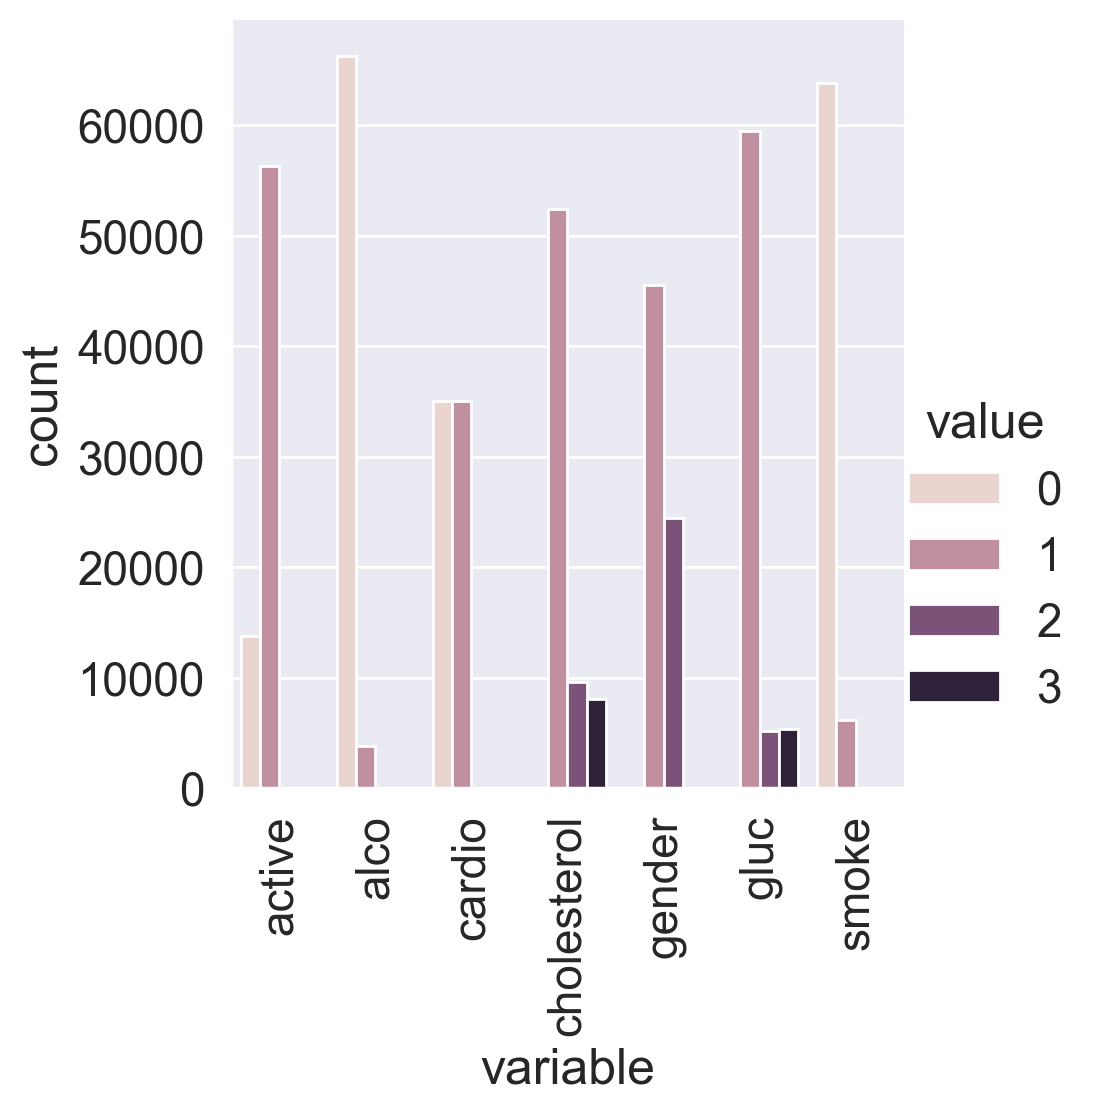

In [27]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]
)

#pd.melt produces variable(column name) and value(number)

df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value"])["value"].count())
    .sort_index(level=[0,1])
    .rename(columns={"value" : "count"})
    .reset_index()
)

sns.catplot(
    x="variable", y="count", hue="value", data=df_uniques, kind="bar"
)

plt.xticks(rotation= "vertical")

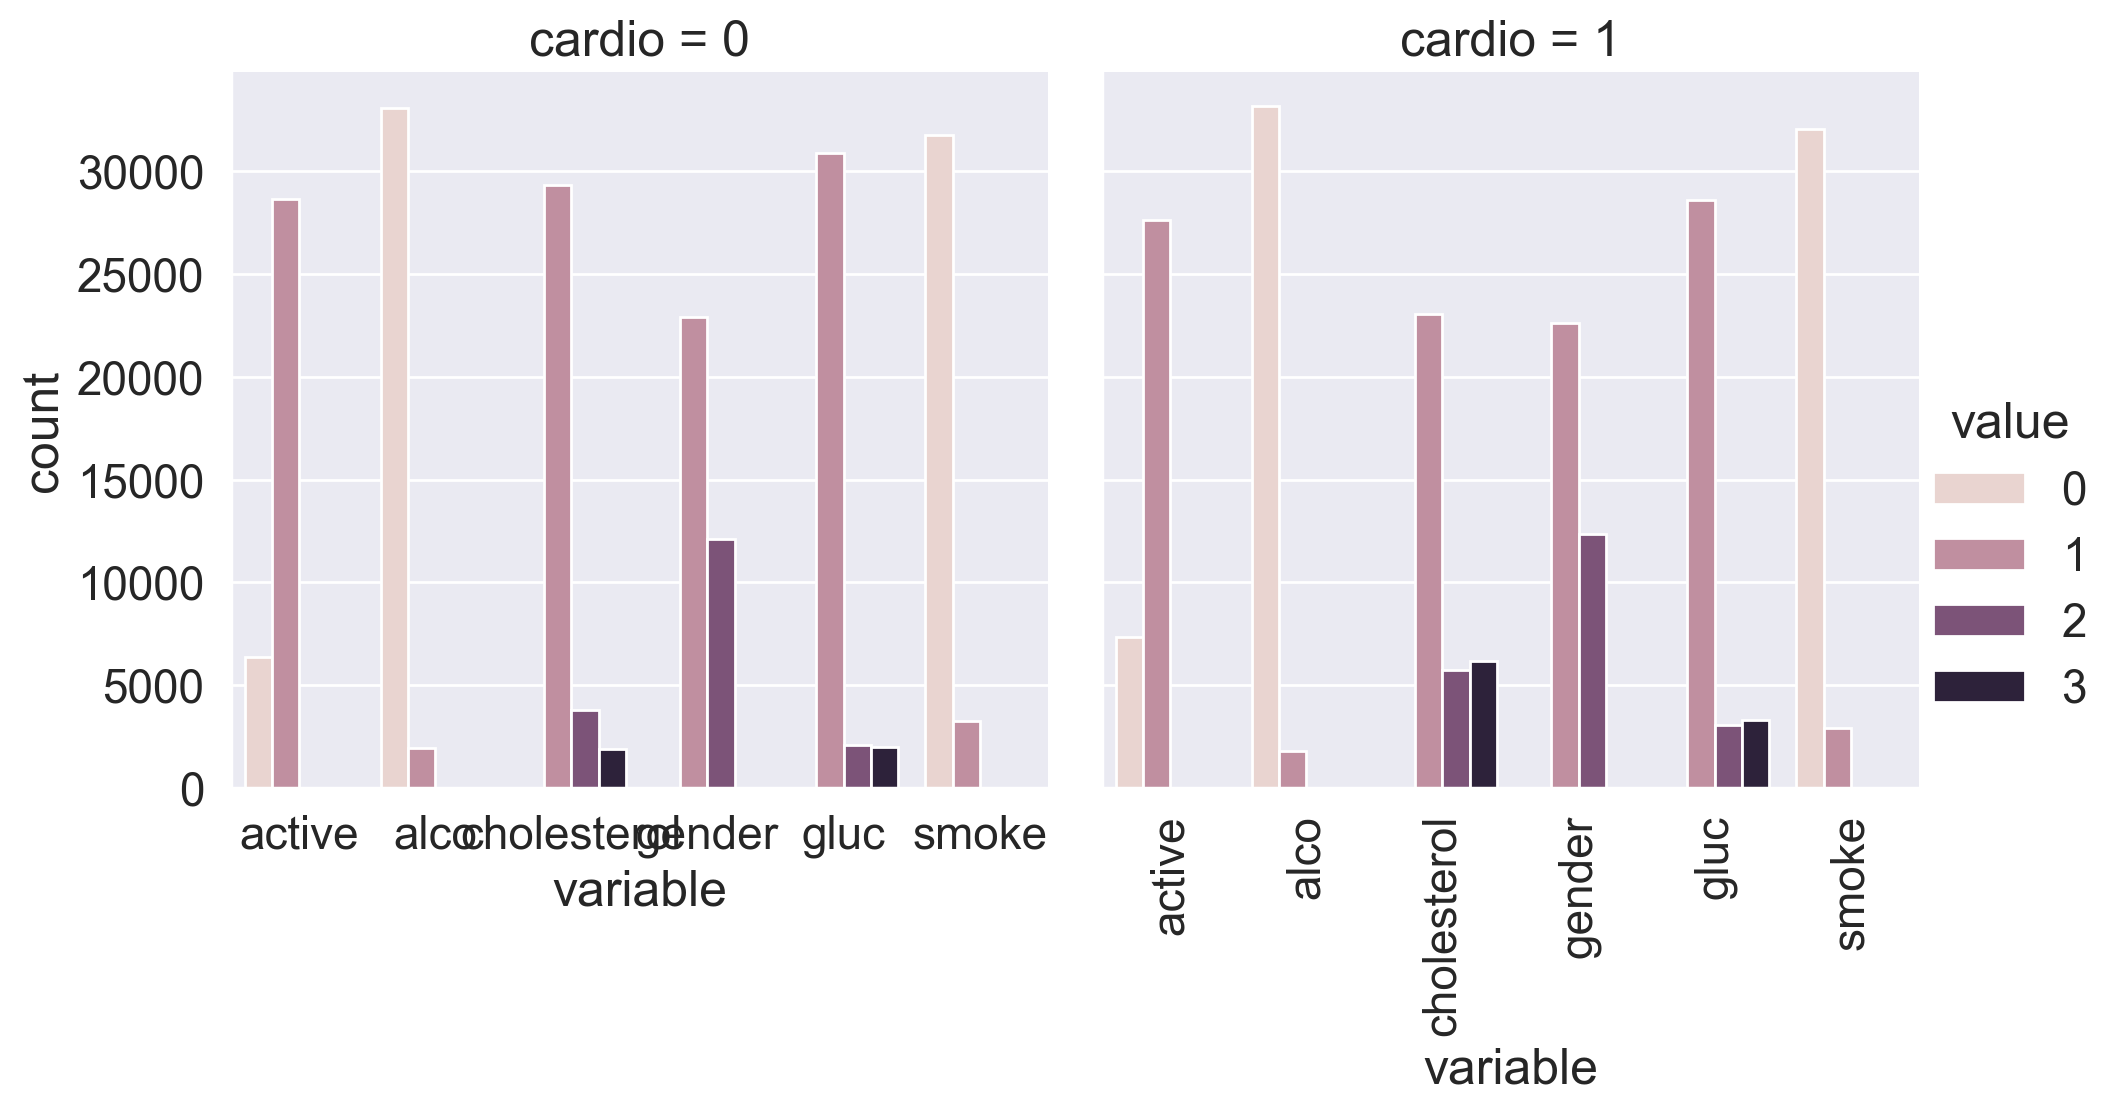

In [28]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
    id_vars=["cardio"]
)

df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
    .sort_index(level=[0,1]) #sorts by variable and value
    .rename(columns={"value":"count"})
    .reset_index() #moves variables and values from index to columns
)

sns.catplot(
    x="variable",
    y="count",
    hue="value",
    col="cardio",
    data=df_uniques,
    kind="bar",
)
plt.xticks(rotation='vertical');

Distribution of cholestrol and glucose differs by value of target variable

In [29]:
for c in df.columns:
    n = df[c].nunique()
    print(c)
    if n<=3:
        print(n, sorted(df[c].value_counts().to_dict().items()))
    else:
        print(n)
    print(10*"-")

id
70000
----------
age
8076
----------
gender
2 [(1, 45530), (2, 24470)]
----------
height
109
----------
weight
287
----------
ap_hi
153
----------
ap_lo
157
----------
cholesterol
3 [(1, 52385), (2, 9549), (3, 8066)]
----------
gluc
3 [(1, 59479), (2, 5190), (3, 5331)]
----------
smoke
2 [(0, 63831), (1, 6169)]
----------
alco
2 [(0, 66236), (1, 3764)]
----------
active
2 [(0, 13739), (1, 56261)]
----------
cardio
2 [(0, 35021), (1, 34979)]
----------


In [30]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [41]:
df.groupby("gender")["height"].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
1,45530.0,161.355612,7.052726,55.0,157.0,161.0,166.0,250.0
2,24470.0,169.947895,7.228895,65.0,165.0,170.0,175.0,207.0


<Axes: xlabel='gender', ylabel='height'>

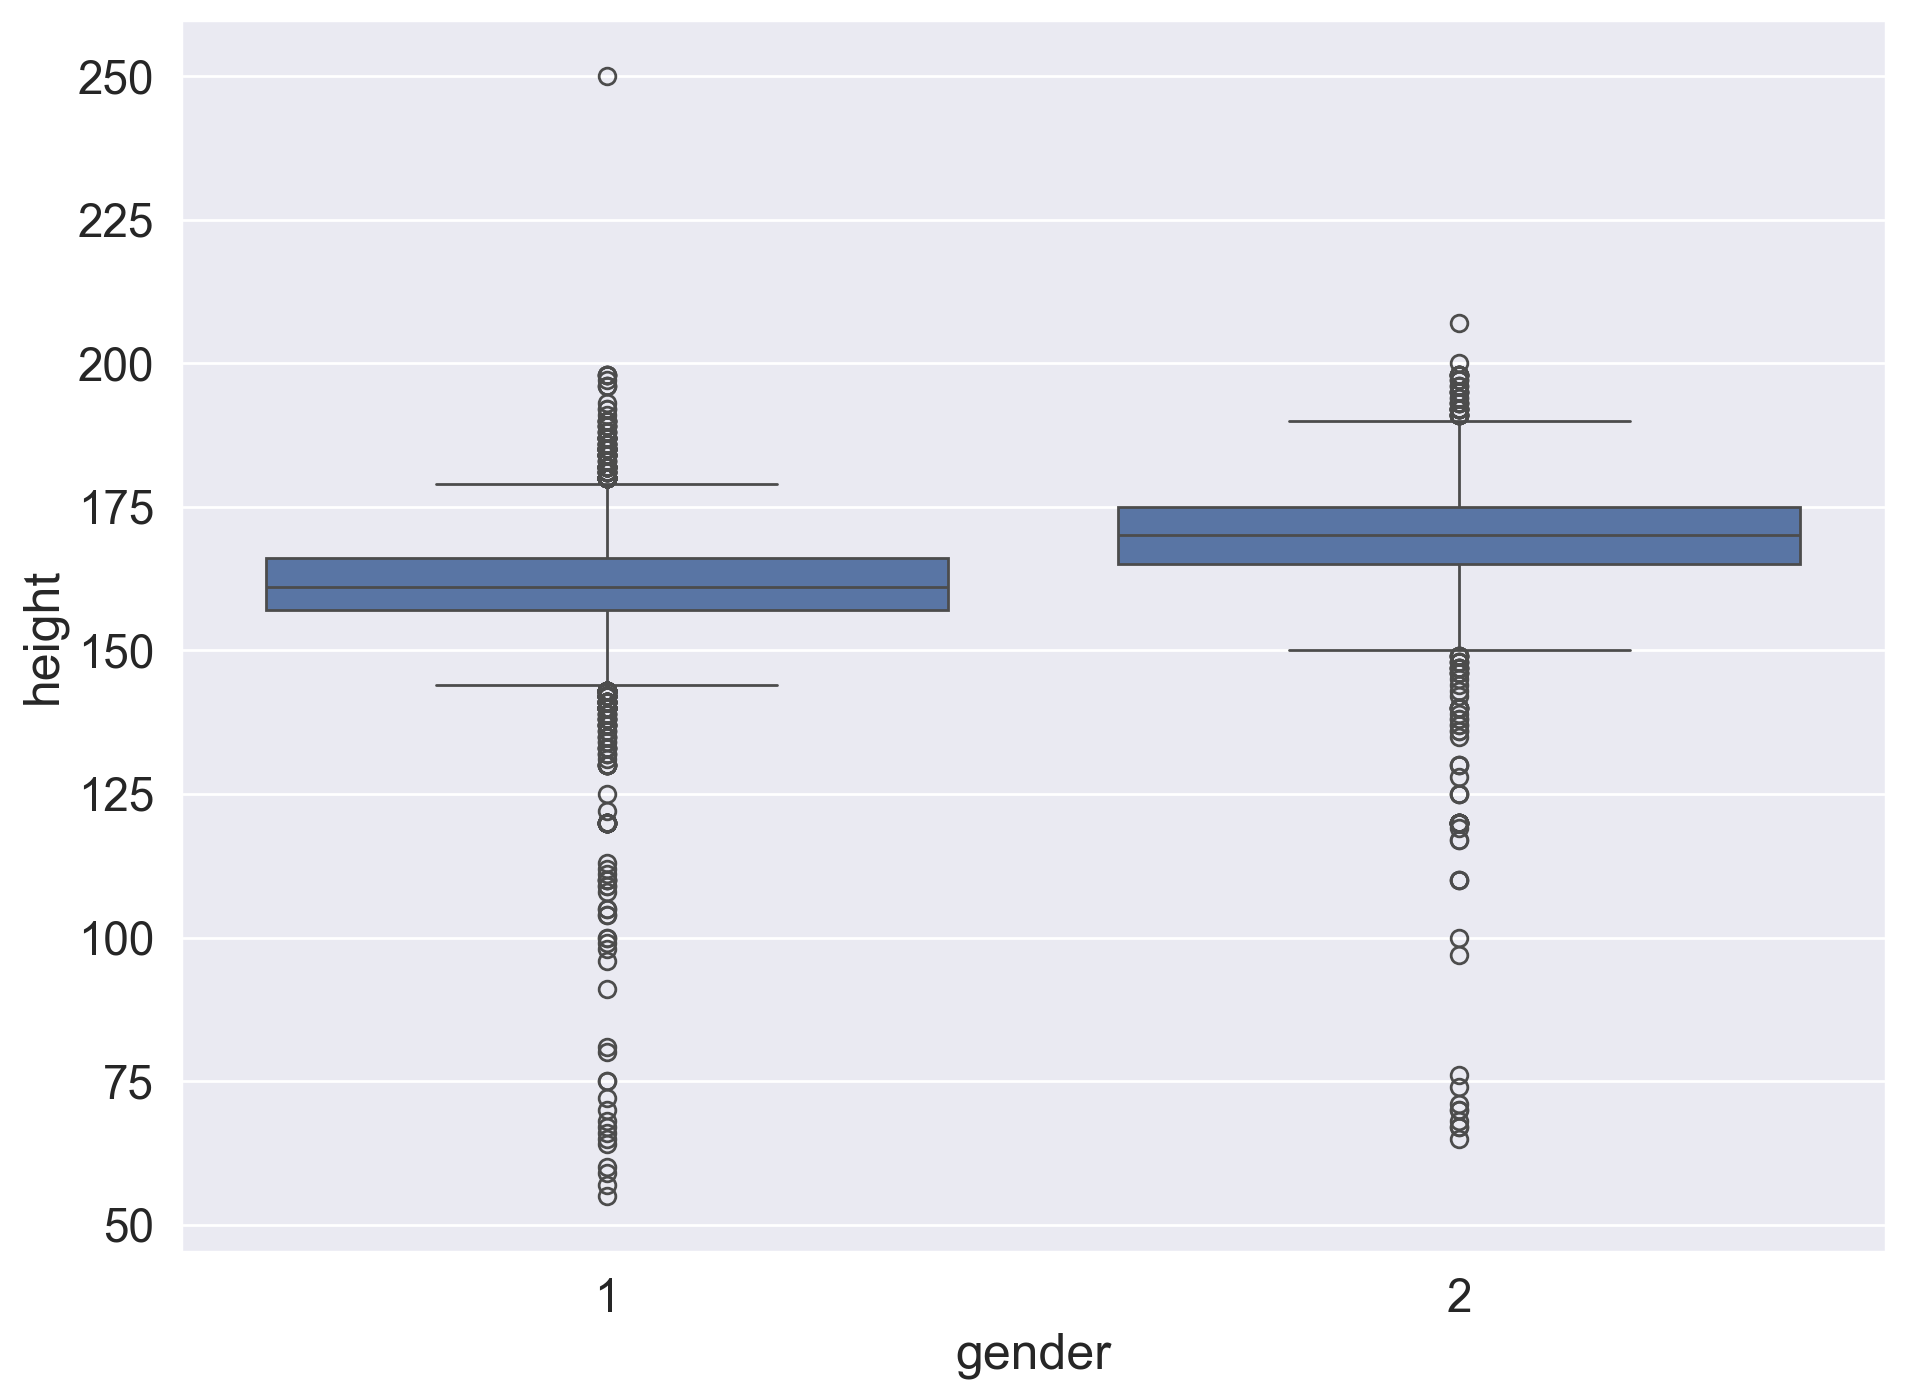

In [32]:
gender_group = df.groupby(
    ["gender"]
)["height"]

sns.boxplot(x="gender" , y="height" , data=df)

Question 1.1. (1 point). How many men and women are present in this dataset? Values of the gender feature were not given (whether “1” stands for women or for men) – figure this out by analyzing height, making the assumption that men are taller on average.

A. 45530 women and 24470 men



Question 1.2. (1 point). Who more often report consuming alcohol – men or women?

In [43]:
df.groupby("gender")["alco"].mean() * 100

gender
1     2.549967
2    10.637515
Name: alco, dtype: float64

<Axes: xlabel='gender', ylabel='count'>

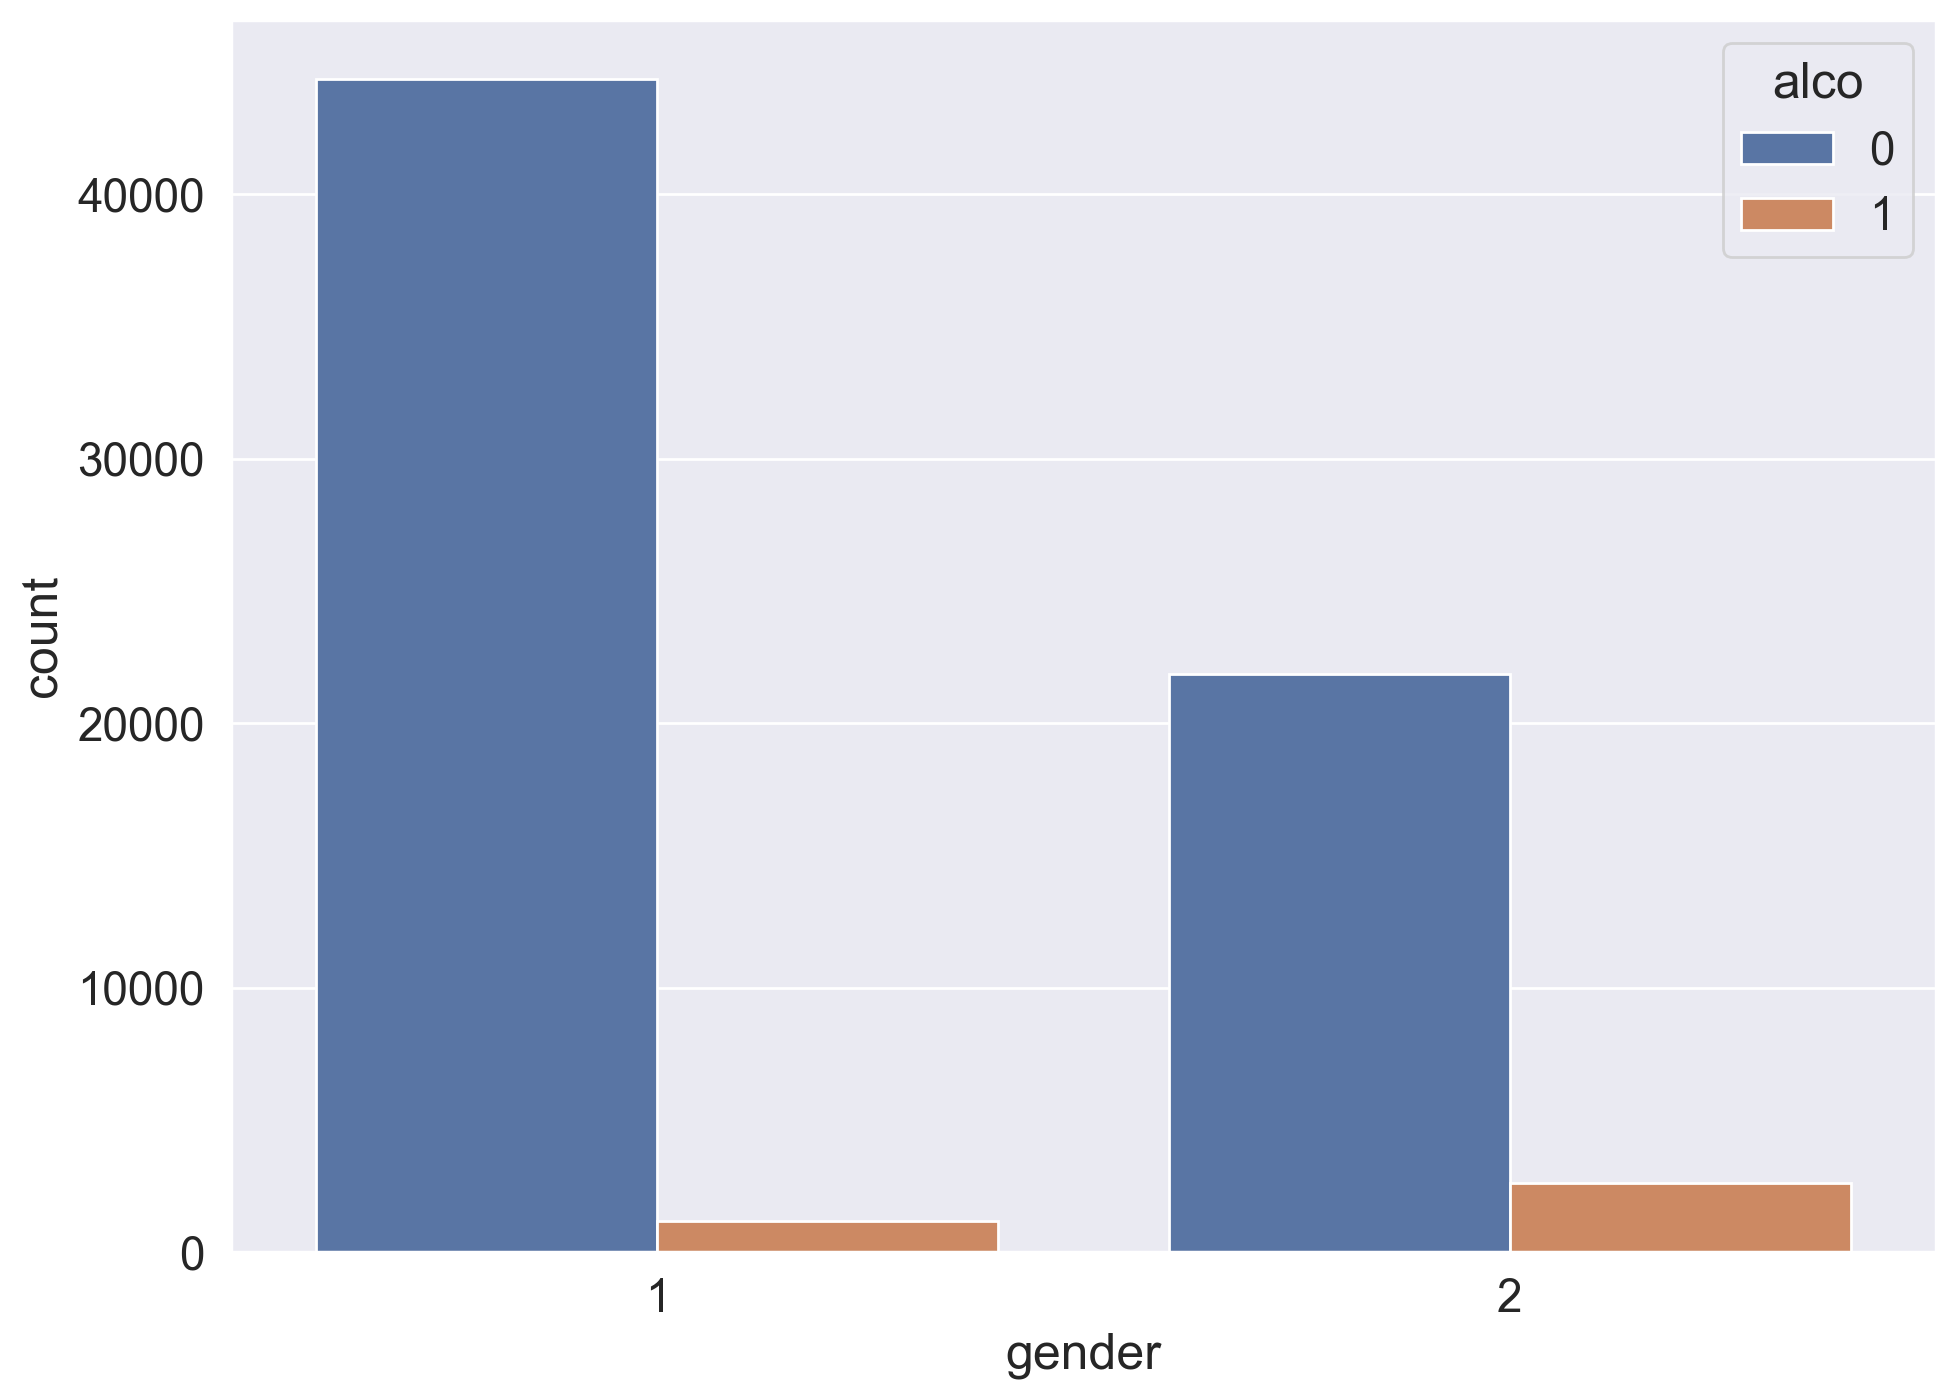

In [33]:
sns.countplot(
    x="gender", hue="alco", data=df
)

Question 1.2. (1 point). Who more often report consuming alcohol – men or women?
A. men

Question 1.3. (1 point). What’s the rounded difference between the percentages of smokers among men and women? 

A. 20

In [46]:
df.groupby("gender")["smoke"].mean()

gender
1    0.017856
2    0.218880
Name: smoke, dtype: float64

In [49]:
round(
    100 * (
        df.loc[df["gender"] == 2, "smoke"].mean()
        - df.loc[df["gender"] == 1, "smoke"].mean()
    )
)

20

Question 1.4. (1 point). What’s the rounded difference between median values of age (in months) for non-smokers and smokers? You’ll need to figure out the units of feature age in this dataset.

In [ ]:
#unit of feature age in the dataset

df["age"].describe()

#age given here is in days

count    70000.000000
mean     19468.865814
std       2467.251667
min      10798.000000
25%      17664.000000
50%      19703.000000
75%      21327.000000
max      23713.000000
Name: age, dtype: float64

In [52]:
df.groupby("smoke")["age"].mean() /365

smoke
0    53.439454
1    52.303663
Name: age, dtype: float64

In [53]:
(
    df[df["smoke"] == 0]["age"].median() - df[df["smoke"] == 1]["age"].median()
) / 365.25 * 12

np.float64(19.613963039014372)

1.2. Risk maps